# Computational Physics, Round-off and Truncation Errors

# 1. Round-off Errors
Round-off errors result from computers' finite bit representations of numbers, which are generally 32 bits for single precision and 64 bits for double precision. The intrinsic constraint is that most real numbers cannot be expressed with absolute precision.

+ The Cause: The root cause of this is the IEEE 754 standard for floating-point arithmetic. Because computers employ base-2 storage, even a simple decimal number such as $0.1$ becomes an indefinitely repeating binary fraction, forcing the computer to truncate the trailing digits.
+  The possibility of major inaccuracy, known as loss of significance, is especially high when subtracting two almost similar integers. If two values are accurate to 10 digits and agree on the first nine, their difference is only one digit of meaningful accuracy.
+  Machine epsilon ($\epsilon_m$) is defined as the smallest positive integer that, when added to 1.0, yields a value that is not 1.0. For 64-bit double precision, $\epsilon_m$ is around $10^{-16}$.
# 2. Truncation Errors
Truncation errors are purely mathematical. They occur when we approximate an infinite process or a continuous function with a finite number of steps.
+ The Cause: Most numerical methods are derived from the Taylor Series Expansion. To make a calculation possible, we "truncate" the infinite series after a few terms.
+ Example: The derivative of a function $f(x)$ is defined as a limit, but in code, we use a finite difference:$$f'(x) \approx \frac{f(x + h) - f(x)}{h}$$The terms we throw away constitute the truncation error, which in this case is proportional to the step size $h$ (denoted as $O(h)$).
  
  #  The "Numerical Tightrope"

  The most frustrating aspect of computational physics is the trade-off between these two errors.
 <table>
  <tr>
    <td>Error Type</td>
    <td>Behavior as Step Size (h) Decreases.</td>
  </tr>
  <tr>
    <td>Truncation Error</td>
    <td>Decreases. A smaller $h$ makes your mathematical approximation more "perfect."<td>
    </tr>
    <tr>
        <td>Round-off Error </td>     <td> Increases. As $h$ gets tiny, you are often subtracting very similar numbers and dividing by near-zero, magnifying precision limits.</td>
  </tr>
</table>   
 
   

we shall use the subtractive cancellation between $x = 1$ and $y = 1.0 + 10^{-15} \sqrt{2}$   to demonstrate 

In [5]:
import math 
x= 1.0
y=1.0+1e-15 * math.sqrt(2)
dt=1e-15 * math.sqrt(2)           #  1.4142135623730953e-15
dn= y - x                         #  1.3322676295501878e-15
print (dt,dn)  # example is from Ernazar abdikamalov

1.4142135623730953e-15 1.3322676295501878e-15


Even though mathematically, $$ dt + x = y $$  but we can notice that there is a huge difference in expected value when we checked for $$ dn = y - x $$ which suppossed to give same value as dt, (ie dt = dn is the expected outcome) but their is a huge 0.06150861208762892 (6%) error in the computed outcome.

To understand how we assess accuracy in computational physics, we first examine the structure of an approximation. 
When we calculate something numerically, we are effectively bridging the gap between the discrete numbers that a computer knows and the continuous mathematics of the real world.
### 1. The True Value ($A_{true}$)
 The True Value is the exact analytical solution obtained through pure mathematics (calculus, algebra, etc.). In most real-world physics problems (like complex fluid dynamics or many-body quantum systems), the true value is unknown, which is why we use computers to find an approximation.
### 2. Total Error ($E_{tot}$)
The Total Error is the absolute difference between the exact mathematical result and the value actually produced by your code. It is the sum of two distinct "evils":$$E_{tot} = |A_{true} - A_{calc}| \approx \text{Truncation Error} + \text{Round-off Error}$$Round-off Error: Stems from the hardware (finite precision).Truncation Error: Stems from the algorithm (the mathematical shortcut). 
### 3. Truncation Error via Taylor Series
The Taylor Series is the "DNA" of numerical analysis. It tells us that any smooth function $f(x)$ can be expressed as an infinite sum of its derivatives at a point $x$:$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2!}f''(x) + \frac{h^3}{3!}f'''(x) + \dots$$
#### Estimating the Error
When we program a derivative (like the Forward Difference method), we rearrange the Taylor Series to solve for $f'(x)$:$$f'(x) = \frac{f(x+h) - f(x)}{h} - \left[ \frac{h}{2}f''(x) + \frac{h^2}{6}f'''(x) + \dots \right]$$The part inside the brackets is what we truncate (throw away) to make the calculation finite.
+ Leading Order Term: The first term we throw away is the most significant. Here, it is $\frac{h}{2}f''(x)$.
+ Big-O Notation: Since the most significant part of the error is proportional to $h$, we say the truncation error is $O(h)$.
  ##### Insight:

### 4. Summary Table: Error Estimates


   

| Method | Formula | Truncation Error Estimate | Order |
|---|---|---|---|
| Forward Difference | $\dfrac{f(x+h)-f(x)}{h}$ | $\approx \dfrac{h}{2}f''(x)$ | $O(h)$ |
| Central Difference | $\dfrac{f(x+h)-f(x-h)}{2h}$ | $\approx \dfrac{h^2}{6}f'''(x)$ | $O(h^2)$ |
| Runge-Kutta (RK4) | Weighted average of slopes | $\approx C \cdot h^4$ | $O(h^4)$ |

In the expression $\text{Error} \approx C \cdot h^4$, the $C$ represents a proportionality constant that depends on the specific behavior of the function you are integrating (specifically its higher-order derivatives) and the details of the Runge-Kutta algorithm itself.

While the $h^4$ tells you how the error scales (the "rate" of convergence), the $C$ tells you the magnitude of the error for a specific problem.


In the Taylor Series expansion for a fourth-order method like RK4, the local truncation error is formally the first term that we "throw away." For RK4, the series matches the true solution up to the $h^4$ term. The error, therefore, starts at the $h^5$ term:$$\text{Local Error} = \frac{h^5}{120} f^{(5)}(\xi)$$When you move from Local Error (error in one step) to Global Error (total error over the whole interval), you lose one power of $h$ because you are taking roughly $1/h$ steps. This leads to the Global Error:$$\text{Global Error} \approx C \cdot h^4$$

### The components of $C$:
+ The 5th Derivative: $C$ is heavily dependent on $f^{(5)}(x)$. If your function is "wiggly" or changes rapidly (high 5th derivative), $C$ will be large, and your error will be higher even with a small $h$.
+ The Algorithm Coefficients: RK4 uses specific "weights" (the 1/6, 1/3, 1/3, 1/6 distribution). These numbers are baked into the constant $C$.
+ The Integration Interval: The longer the total distance you are integrating, the larger $C$ becomes as errors accumulate.

##### The Total Error Minimum
If you plot the total error, it forms a "U-shape." If $h$ is too large, truncation error dominates. If $h$ is too small, round-off error takes over.

To show  the U-curve using a Taylor Series method, we will use a polynomial $f(x) = x^3$. This is ideal because it has a simple  higher-order derivatives, making the Taylor Series truncation error estimate ($O(h)$ for forward difference) very easy to calculate and verify.The "True Value" of the derivative at $x=1$ for $f(x)=x^3$ is exactly $3x^2 = 3$.

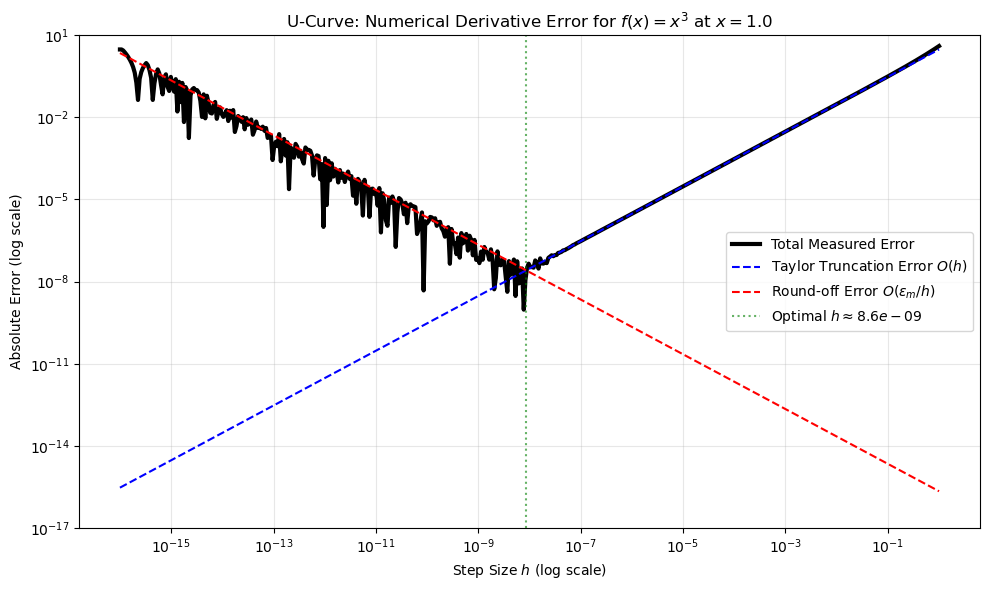

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Function and its Analytical Derivatives
def f(x):
    return x**3

def df_true(x):
    return 3 * x**2  # Exact first derivative

def d2f_true(x):
    return 6 * x     # Exact second derivative (used for Taylor truncation estimate)

# Constants
x_0 = 1.0
m_eps = np.finfo(float).eps  # ~2.22e-16

# 2. Generate range of step sizes (h) from 10^-16 to 10^0
h = np.logspace(-16, 0, 500)

# 3. Calculate Numerical Derivative (Forward Difference)
# Formula: [f(x+h) - f(x)] / h
df_num = (f(x_0 + h) - f(x_0)) / h

# 4. Calculate Errors
# Total measured error
total_error = np.abs(df_num - df_true(x_0))

# Truncation Error Estimate from Taylor Series:
# f(x+h) = f(x) + hf'(x) + (h^2/2)f''(x) + ...
# (f(x+h) - f(x))/h = f'(x) + (h/2)f''(x)
# So, Truncation Error approx = (h/2) * |f''(x)|
truncation_err = (h / 2.0) * np.abs(d2f_true(x_0))

# Round-off Error Estimate:
# Errors in f(x) are ~ epsilon. Subtraction magnification/h gives:
roundoff_err = m_eps / h

# 5. Plotting
plt.figure(figsize=(10, 6))

plt.loglog(h, total_error, 'k-', lw=3, label='Total Measured Error')
plt.loglog(h, truncation_err, 'b--', label='Taylor Truncation Error $O(h)$')
plt.loglog(h, roundoff_err, 'r--', label='Round-off Error $O(\\epsilon_m/h)$')

# Theoretical optimal h is where Trunc_Err = Round_Err
# (h/2)f'' = eps/h  =>  h^2 = 2*eps/f'' => h = sqrt(2*eps/f'')
opt_h = np.sqrt(2 * m_eps / np.abs(d2f_true(x_0)))
plt.axvline(opt_h, color='green', linestyle=':', alpha=0.6, label=f'Optimal $h \\approx {opt_h:.1e}$')

plt.title(f'U-Curve: Numerical Derivative Error for $f(x)=x^3$ at $x={x_0}$')
plt.xlabel('Step Size $h$ (log scale)')
plt.ylabel('Absolute Error (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.ylim(1e-17, 10)

plt.tight_layout()
plt.show()

### Important Takeaways :
+ Taylor Truncation: Observe that $f''(x) = 6$ for $x=1$. As a result, the truncation error is roughly $3h$. This shows up as a straight line with a slope of $1$ on the log-log plot.
+ Round-off Slope: Due to its proportionality to $1/h$, the round-off error has a slope of $-1$.
+ The Intersection: The mathematical "sweet spot" is the intersection of the two dashed lines. This often happens at $h \approx 10^{-8}$ for first-order techniques on a 64-bit machine.
+ Precision Floor: Despite the machine epsilon being $10^{-16}$, observe that the error never falls below about $10^{-9}$ or $10^{-10}$. This is the "cost" of adopting a first-order approximation; the sum of these two inaccuracies causes you to lose almost half of your significant numbers.

To calculate machine epsilon ($\epsilon_m$), we start with $1.0$ and repeatedly divide a value by $2.0$ until the computer can no longer distinguish the difference between $1.0$ and $1.0 + \text{eps}$.The following script demonstrates this for standard 64-bit floats:

In [15]:
def calculate_machine_epsilon():
    epsilon = 1.0
    # Keep dividing by 2 until 1.0 + epsilon is no longer greater than 1.0
    while (1.0 + epsilon / 2.0) > 1.0:
        epsilon /= 2.0
    return epsilon

if __name__ == "__main__":
    eps = calculate_machine_epsilon()
    
    print(f"Calculated Machine Epsilon: {eps:.2e}")
    print(f"Verification (1.0 + eps):    {1.0 + eps}")
    print(f"Verification (1.0 + eps/2):  {1.0 + eps/2.0}")
    
    # Compare with NumPy's built-in precision tool
    import numpy as np
    print(f"NumPy Double Precision:     {np.finfo(float).eps:.2e}")

Calculated Machine Epsilon: 2.22e-16
Verification (1.0 + eps):    1.0000000000000002
Verification (1.0 + eps/2):  1.0
NumPy Double Precision:     2.22e-16


#### Why This Works. 
Binary floating-point representation stores numbers as: $$(-1)^s \times (1.m) \times 2^{e-1023}$$.
The "1" preceding the mantissa ($m$) is implied. Machine epsilon is the value of the least significant bit in the mantissa when the exponent is zero (i.e., $1.0$).
+ Double Precision (64-bit): The mantissa occupies 52 bits. Therefore, $\epsilon_m = 2^{-52} \approx 2.22 \times. 10^{-16}$.
+  Single Precision (32-bit): The mantissa takes up 23 bits. Thus, $\epsilon_m = 2^{-23} \approx. 1.19 \times 10^{-7}$.Real-world Tip

### Real-World Tip
When writing convergence criteria for simulations (like a Root Finding algorithm), never check if error == 0. Instead, check if error < tolerance, where your tolerance is typically a few orders of magnitude larger than $\epsilon_m$.

## Optimal Step Size
To find the optimal step size ($h_{opt}$), we have to find the "bottom" of that U-curve where the Truncation Error and 
Round-off Error are roughly equal.

If $h$ is larger than $h_{opt}$, your math is too simple (Truncation dominated). 
If $h$ is smaller, your computer is "stuttering" over tiny decimals (Round-off dominated

#### 1. The Mathematical Derivation
We can estimate $h_{opt}$ by setting the two error components equal to each other. Let's use the Forward Difference derivative as an example:
+ Truncation Error ($E_{trunc}$): From the Taylor Series, $E_{trunc} \approx \frac{h}{2}|f''(x)|$.
+ Round-off Error ($E_{round}$): Since we calculate $\frac{f(x+h) - f(x)}{h}$, and each function evaluation has a relative error of machine epsilon ($\epsilon_m$), the numerator has an error of roughly $\epsilon_m |f(x)|$. Thus, $E_{round} \approx \frac{\epsilon_m |f(x)|}{h}$.To find the minimum, we set $E_{trunc} \approx E_{round}$:$$\frac{h}{2}|f''(x)| \approx \frac{\epsilon_m |f(x)|}{h}$$Solving for $h$:$$h^2 \approx \frac{2 \epsilon_m |f(x)|}{|f''(x)|} \implies \mathbf{h_{opt} \approx \sqrt{\epsilon_m} \sqrt{\frac{2|f(x)|}{|f''(x)|}}}$$

#### 2. Rule of Thumb for Different Methods
The optimal step size changes depending on the order of your numerical method. Because higher-order methods reduce truncation error faster, they allow (and require) a larger $h$ to stay away from the round-off "cliff."

| Method | Error Order | Optimal $h$ Formula | Approx $h_\text{opt}$ (Double Precision) |
|---|---|---|---|
| Forward Difference | $O(h)$ | $\sqrt{\epsilon_m}$ | $\sim 10^{-8}$ |
| Central Difference | $O(h^2)$ | $\sqrt[3]{\epsilon_m}$ | $\sim 10^{-5}$ |
| RK4 / Five-Point | $O(h^4)$ | $\sqrt[5]{\epsilon_m}$ | $\sim 10^{-3}$ |

### 3. Python Function to Calculate $h_{opt}$
This script takes any function and automatically estimates the best $h$ to use for a forward difference derivative.

In [19]:
import numpy as np

def get_optimal_h(f, x):
    eps = np.finfo(float).eps
    
    # We need a rough estimate of f(x) and f''(x)
    # If unknown, we assume the ratio |f/f''| is ~ 1
    # For a more robust version, one could numerically estimate f''
    val_f = np.abs(f(x))
    
    # Simple heuristic for f''(x) if not provided:
    # We use a slightly large h to avoid roundoff while estimating the second derivative
    h_est = 1e-4
    d2f_est = np.abs((f(x + h_est) - 2*f(x) + f(x - h_est)) / h_est**2)
    
    # Avoid division by zero
    if d2f_est == 0: d2f_est = 1.0
    
    h_opt = np.sqrt((2 * eps * val_f) / d2f_est)
    return h_opt

# Example: f(x) = x^3 at x = 1.0
func = lambda x: x**3
best_h = get_optimal_h(func, 1.0)

print(f"Optimal h for Forward Difference: {best_h:.2e}")

Optimal h for Forward Difference: 8.60e-09


### Best Lab Practices 
+ Use Double Precision: Unless you are hardware-constrained (like on some GPUs), always use float64 or double.
+ Avoid Small Differences: Rewrite formulas to avoid subtracting similar numbers. For example, use $\sqrt{x+1} - \sqrt{x} = \frac{1}{\sqrt{x+1} + \sqrt{x}}$.
+ Order of Operations: When summing a long list of numbers, sort them from smallest to largest first. Adding a tiny number to a massive sum often results in the tiny number being "rounded out" of existence.